Dataset Shape: (569, 30)
Target Distribution: [212 357] (0: malignant, 1: benign)

--- Baseline Logistic Regression ---
Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



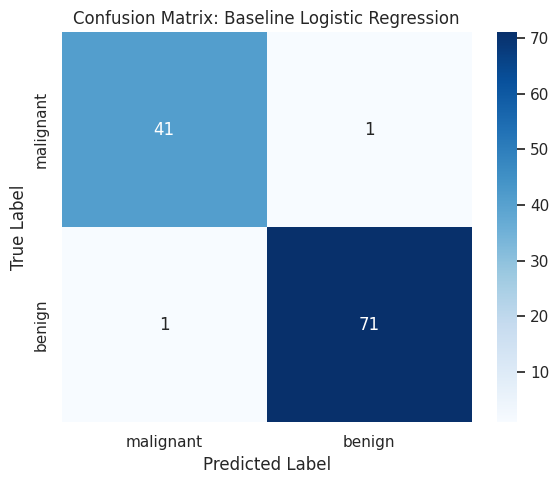


--- Balanced Logistic Regression ---
Confusion Matrix:
 [[41  1]
 [ 4 68]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Decision Tree Classifier ---
Confusion Matrix:
 [[39  3]
 [ 6 66]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



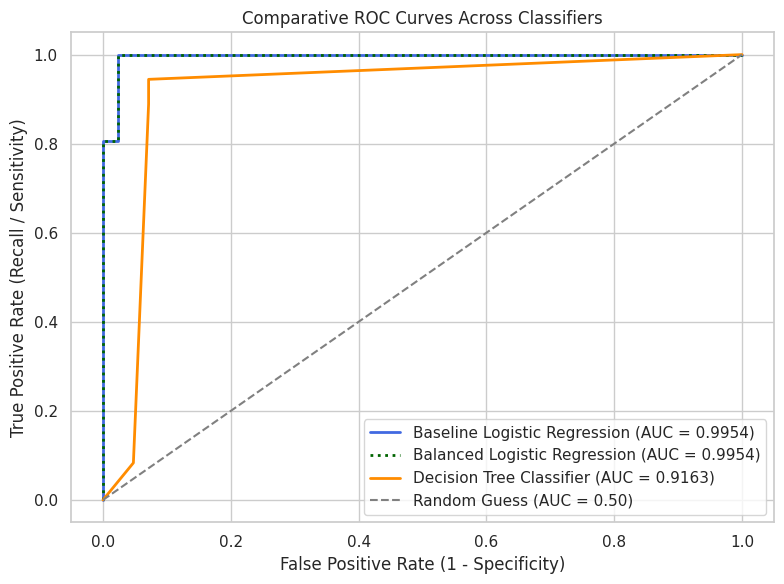

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

# ------------------------------------------------------------------------------
# Steps 1 & 2: Load and Prepare Dataset
# ------------------------------------------------------------------------------
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
target_names = data.target_names

print(f"Dataset Shape: {X.shape}")
print(f"Target Distribution: {np.bincount(y)} (0: {target_names[0]}, 1: {target_names[1]})")

# ------------------------------------------------------------------------------
# Step 3: Stratified Train-Test Split (80/20)
# ------------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------------------------------------------------------
# Step 4: Feature Standardization
# ------------------------------------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------------------
# Step 5: Baseline Logistic Regression Model
# ------------------------------------------------------------------------------
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_lr = lr_baseline.predict(X_test_scaled)
y_prob_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------------------------
# Step 6 & 7: Confusion Matrix & Metric Reporting
# ------------------------------------------------------------------------------
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\n--- Baseline Logistic Regression ---")
print("Confusion Matrix:\n", cm_lr)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=target_names))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix: Baseline Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Step 8: Cost-Sensitive Logistic Regression (Balanced Class Weights)
# ------------------------------------------------------------------------------
lr_balanced = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr_balanced.fit(X_train_scaled, y_train)

y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

cm_bal = confusion_matrix(y_test, y_pred_bal)
print("\n--- Balanced Logistic Regression ---")
print("Confusion Matrix:\n", cm_bal)
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal, target_names=target_names))

# ------------------------------------------------------------------------------
# Step 9: Comparative Classifier: Decision Tree
# ------------------------------------------------------------------------------
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train, y_train)

y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

cm_dt = confusion_matrix(y_test, y_pred_dt)
print("\n--- Decision Tree Classifier ---")
print("Confusion Matrix:\n", cm_dt)
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=target_names))

# ------------------------------------------------------------------------------
# Step 10: Comparative ROC Curves & AUC Analysis
# ------------------------------------------------------------------------------
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)
auc_bal = roc_auc_score(y_test, y_prob_bal)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Baseline Logistic Regression (AUC = {auc_lr:.4f})", color="royalblue", lw=2)
plt.plot(fpr_bal, tpr_bal, label=f"Balanced Logistic Regression (AUC = {auc_bal:.4f})", color="darkgreen", lw=2, linestyle=":")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree Classifier (AUC = {auc_dt:.4f})", color="darkorange", lw=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1.5, label="Random Guess (AUC = 0.50)")

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall / Sensitivity)")
plt.title("Comparative ROC Curves Across Classifiers")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Step 11: Summary Comparison Table
# ------------------------------------------------------------------------------
models_summary = [
    {
        "Model": "Logistic Regression (Baseline)",
        "Accuracy": accuracy_score(y_test, y_pred_lr),
        "Precision (Malignant)": precision_score(y_test, y_pred_lr, pos_label=0),
        "Recall (Malignant)": recall_score(y_test, y_pred_lr, pos_label=0),
        "F1-Score (Malignant)": f1_score(y_test, y_pred_lr, pos_label=0),
        "ROC-AUC": auc_lr
    },
    {
        "Model": "Logistic Regression (Balanced)",
        "Accuracy": accuracy_score(y_test, y_pred_bal),
        "Precision (Malignant)": precision_score(y_test, y_pred_bal, pos_label=0),
        "Recall (Malignant)": recall_score(y_test, y_pred_bal, pos_label=0),
        "F1-Score (Malignant)": f1_score(y_test, y_pred_bal, pos_label=0),
        "ROC-AUC": auc_bal
    }
]